Navpreet Kloy, Angel Vasquez

In [ ]:
# import requried libaries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split



In [ ]:
# reads and stores csv file
df=pd.read_csv('garments_worker_productivity.csv')
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [ ]:
# Displays number of missing (NaN) values in each column
print(df.isnull().sum())
#(rows, columns) in dataframe
print(df.shape)


date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64
(1197, 15)


In [ ]:
# check unique values in the 'department' column
print(df['department'].unique())

['sweing' 'finishing ' 'finishing']


In [ ]:
# remove leading/trailing whitespace from 'department' values
df['department'] = df['department'].str.strip()

# filter dataset to include only the sewing department
df = df[df['department'] == 'sweing']

In [ ]:
# recheck dataframe after filtering for sewing department
print(df.shape) #(rows, columns)

(691, 15)


In [ ]:
# compute correlation of all numeric features with 'actual_productivity' and sort from highest to lowest
print(df.corr(numeric_only=True)['actual_productivity']
      .sort_values(ascending=False))

actual_productivity      1.000000
incentive                0.804149
targeted_productivity    0.697970
wip                      0.131147
no_of_workers            0.003378
over_time               -0.016875
idle_time               -0.113737
team                    -0.125099
smv                     -0.155676
idle_men                -0.258357
no_of_style_change      -0.281686
Name: actual_productivity, dtype: float64


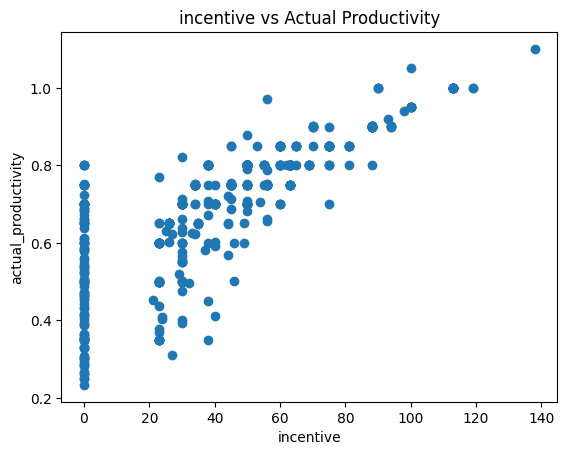

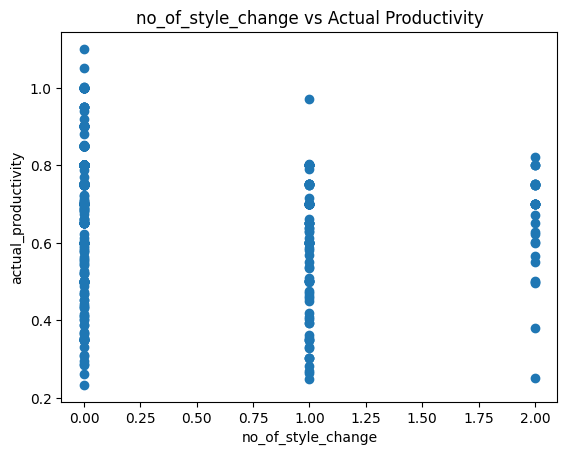

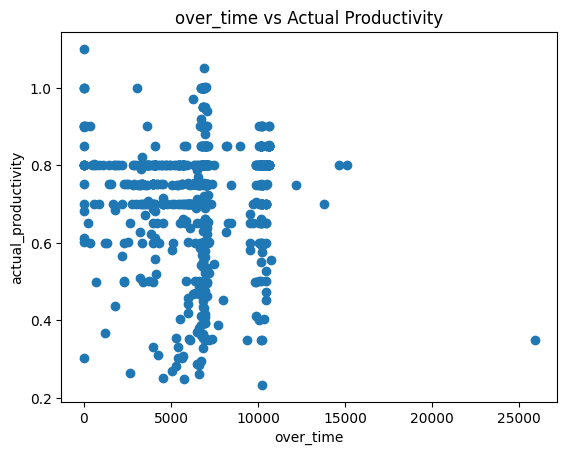

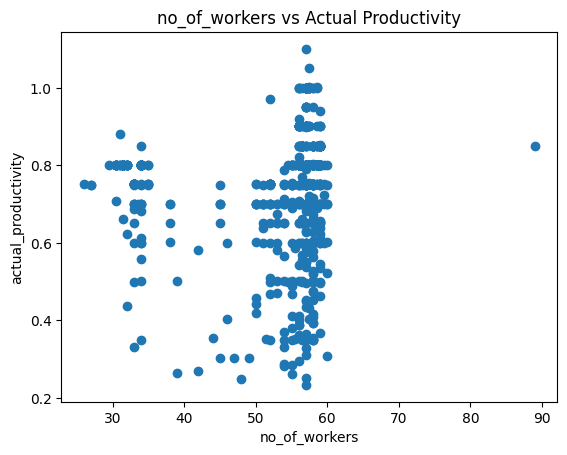

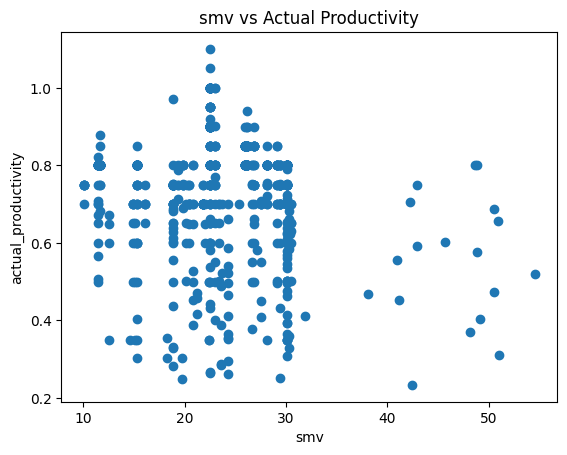

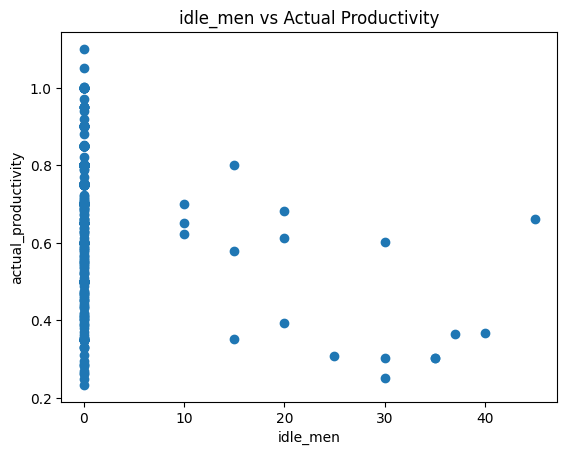

In [ ]:
# plot scatter plots of selected features against 'actual_productivity'

features = ['incentive','no_of_style_change','over_time','no_of_workers','smv','idle_men']

for col in features:
    plt.figure()
    plt.scatter(df[col], df['actual_productivity'])
    plt.xlabel(col)
    plt.ylabel('actual_productivity')
    plt.title(f'{col} vs Actual Productivity')
    plt.show()

In [ ]:
# Define features (x) and target (y)
x = df[['incentive']]
y = df['actual_productivity']

In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
#Use StandardScaler to normalize the data
from sklearn.preprocessing import StandardScaler

#feature Scaling
from sklearn.preprocessing import StandardScaler
st_x=StandardScaler()
x_train=st_x.fit_transform(x_train)
x_test=st_x.transform(x_test)

# Verify normalization worked correctly - Mean should be close to 0, Std should be exactly 1.0
print('Normalized data stats:')
print('  Mean : {:.6f}  (should be ~0)'.format(x_train.mean()))
print('  Std  : {:.6f}  (should be ~1)'.format(x_train.std()))

Normalized data stats:
  Mean : 0.000000  (should be ~0)
  Std  : 1.000000  (should be ~1)


In [ ]:
# Let's do a regression analysis
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train a linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.00721971681046706
R-squared: 0.6528389476743504


Text(0.5, 1.0, 'Actual vs. Predicted Productivity for Sewing Department')

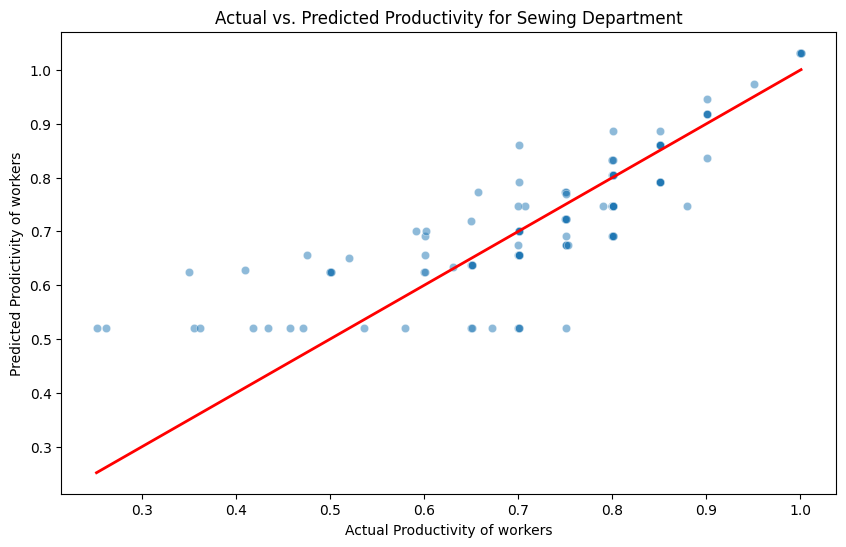

In [ ]:
# plot scatterplot for actual vs. predicted productivity for teams of garment workers for the sewing department
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Productivity of workers')
plt.ylabel('Predicted Prodictivity of workers')
plt.title('Actual vs. Predicted Productivity for Sewing Department')

In [ ]:
# prediction of productivity based on user input

def get_prediction():
    while True:
        try:
            incentive = int(input("Enter incentive amount in Bangladeshi Taka(BDT): "))


            # create input array in the same feature order as training
            input_data = np.array([[incentive]])

            # scale using the to match training data
            input_data_scaled = st_x.transform(input_data)

            # Make prediction
            predicted_productivity = model.predict(input_data_scaled)[0]

            print(f"Predicted productivity: {predicted_productivity:.2f}")
            break  # Exit the loop if input is valid

        except ValueError:
            print("Invalid input. Please enter valid input.")
        except Exception as e:
          print(f"An error occurred: {e}")
          print("Please restart and enter the correct values.")
          break
while True:
    get_prediction()
    another_prediction = input("Do you want another prediction? (yes/no): ")
    if another_prediction.lower() != 'yes':
        break


Enter incentive amount in Bangladeshi Taka(BDT): 45


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted productivity: 0.72
Do you want another prediction? (yes/no): no
